# Primordial Black Hole Evaporation Search Using Fermi-LAT Gamma-Ray Burst Data

## Project Overview

This project investigates whether some gamma-ray bursts (GRBs) observed by NASA's Fermi Large Area Telescope (Fermi-LAT) could be consistent with the theoretical signatures of primordial black hole (PBH) evaporation.

According to Stephen Hawking's theory, small black holes gradually lose mass by emitting Hawking radiation. Primordial black holes with an initial mass of approximately **5 × 10¹¹ kg** are expected to complete their evaporation around the present age of the Universe, producing a burst of high-energy gamma rays.

Using real observational data from the **Fermi-LAT Gamma-Ray Burst Catalog**, this project compares theoretical Hawking radiation predictions with observed GRB properties such as burst duration, photon energy, spectral index, detection significance, and redshift.

The objective is **not** to prove the existence of primordial black holes, but to identify gamma-ray bursts whose characteristics are broadly consistent with theoretical expectations and rank them as potential candidates for further investigation.

### Project Objectives

- Load and explore the Fermi-LAT Gamma-Ray Burst Catalog.
- Clean and prepare the observational data.
- Calculate the Hawking temperature of a primordial black hole evaporating today.
- Compare theoretical predictions with observed gamma-ray burst properties.
- Identify short-duration GRBs that could resemble PBH evaporation.
- Develop a **PBH Consistency Index** to rank candidate events.
- Evaluate whether any observed bursts show characteristics compatible with primordial black hole evaporation.

In [ ]:
!pip -q install astroquery astropy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.2 MB/s eta 0:00:00


In [ ]:
# Import the Heasarc class to access NASA HEASARC astronomical databases
from astroquery.heasarc import Heasarc

# Import pandas for data manipulation and analysis
import pandas as pd

# Import Table to work with Astropy tables returned by astronomical databases
from astropy.table import Table

# Create a connection to the HEASARC database
heasarc = Heasarc()

In [ ]:
# Import the astroquery package for accessing online astronomical databases
import astroquery

# Display the installed version of astroquery
print(astroquery.__version__)

# Import the Heasarc class to query NASA's HEASARC database
from astroquery.heasarc import Heasarc

# Create a HEASARC connection object
heasarc = Heasarc()

# Display all available methods and attributes of the Heasarc object
print(dir(heasarc))

0.4.11
['S3_BUCKET', 'TAR_URL', 'VO_URL', '__abstractmethods__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_cache_location', '_copy_sciserver', '_datalink', '_download_file', '_download_heasarc', '_download_s3', '_get_default_columns', '_meta', '_meta_info', '_request', '_response_hook', '_session', '_set_session', '_tap', 'cache_location', 'clear_cache', 'download_data', 'enable_cloud', 'get_default_radius', 'list_catalogs', 'list_columns', 'locate_data', 'name', 'query_mission_cols', 'query_mission_list', 'query_object', 'query_region', 'query_tap', 'reset_cache_location', 'tap', 'timeout']


In [ ]:
from astroquery.heasarc import Heasarc

heasarc = Heasarc()

query = """
SELECT *
FROM fermilgrb
"""

table = heasarc.query_tap(query)

table

<DALResultsTable length=231>
__row      name      gcn_name  ...      __y_ra_dec         __z_ra_dec    
                               ...                                       
object    object      object   ...       float64            float64      
------ ------------ ---------- ... ------------------- ------------------
     1 GRB140323433 GRB140323A ...   0.174700324780714 -0.984564334529205
     2 GRB190731943 GRB190731A ...   0.221073750310668 -0.972043021443304
     3 GRB160325291 GRB160325A ...   0.286192709871819  -0.95455296002364
     4 GRB210826293 GRB210826A ...   0.221016154051155 -0.949370661159775
     5 GRB201104001 GRB201104A ...  0.0485304532438133 -0.946254831896026
     6 GRB120711115 GRB120711A ... -0.0264969039407634 -0.944834633996098
     7 GRB171212434 GRB171212B ...   0.256216892432148 -0.943396447806689
     8 GRB120107384 GRB120107A ...  -0.140394361286753 -0.943164670527808
     9 GRB130327350 GRB130327B ...   -0.27164560373032 -0.938251730455139
   ...   

In [ ]:
type(table)
dir(table)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_adhocservices',
 '_client_set_maxrec',
 '_findinfos',
 '_findresultsresource',
 '_findresultstable',
 '_findstatus',
 '_findstatusinfo',
 '_fldnames',
 '_from_result_url',
 '_guess_access_format',
 '_guess_access_url',
 '_guess_datalink',
 '_handle_overflow_warning',
 '_infos',
 '_iter_datalinks_from_dlblock',
 '_iter_datalinks_from_product_rows',
 '_resultstable',
 '_session',
 '_status',
 '_url',
 '_votable',
 'broadcast_samp',
 'check_overflow_warning',
 'cursor',
 'fielddescs',
 'fieldname_with_ucd',
 'fieldname_with_utype',
 'fieldnames',
 'from_result_url',

In [ ]:
# Convert TAPResults to an Astropy Table
astro_table = table.to_table()

print(type(astro_table))
astro_table

<class 'astropy.table.table.Table'>


__row,name,gcn_name,time,trigger_met,ra,dec,lii,bii,error_radius,redshift,luminosity_distance,theta,zenith,arr_flag,distance_to_closest,irfs,lle_bbbd_sig,lle_bbbd_sig_detected,lle_t05,lle_t90,lle_t95,tl0,tl100,tl100_error,tl1,tl0_lower,tl1_upper,like_best_t0,like_best_t1,like_best_ts,like_best_flux,like_best_flux_error,like_best_flux_ene,like_best_flux_ene_error,like_best_fluence,like_best_fluence_error,like_best_grbindex,like_best_grbindex_error,like_best_eiso_rf,like_best_eiso_rf_error,like_lat_t0,like_lat_t1,like_lat_ts,like_lat_flux,like_lat_flux_error,like_lat_flux_ene,like_lat_flux_ene_error,like_lat_fluence,like_lat_fluence_error,like_lat_grbindex,like_lat_grbindex_error,like_lat_eiso_rf,like_lat_eiso_rf_error,like_gbm_t0,like_gbm_t1,like_gbm_ts,like_gbm_flux,like_gbm_flux_error,like_gbm_flux_ene,like_gbm_flux_ene_error,like_gbm_fluence,like_gbm_fluence_error,like_gbm_grbindex,like_gbm_grbindex_error,like_gbm_eiso_rf,like_gbm_eiso_rf_error,like_ext_t0,like_ext_t1,like_ext_ts,like_ext_flux,like_ext_flux_error,like_ext_flux_ene,like_ext_flux_ene_error,like_ext_fluence,like_ext_fluence_error,like_ext_grbindex,like_ext_grbindex_error,like_ext_eiso_rf,like_ext_eiso_rf_error,ext_emission_max_ene,ext_emission_max_ene_p,ext_emission_max_ene_t,ext_emission_n,lat_bpl_chi2,lat_bpl_f0,lat_bpl_f0_error,lat_bpl_index1,lat_bpl_index1_error,lat_bpl_index2,lat_bpl_index2_error,lat_bpl_timebreak,lat_bpl_timebreak_error,lat_spl_chi2,lat_spl_index1,lat_spl_index1_error,lat_f0,lat_f0_error,late_index,late_index_error,su_tsinput,gbm_cat_name,gbm_cat_t05,gbm_cat_t90,gbm_cat_t90_error,gbm_cat_t95,gbm_cat_fluence,gbm_cat_fluence_error,__x_ra_dec,__y_ra_dec,__z_ra_dec
,,,d,s,deg,deg,deg,deg,deg,,cm,deg,deg,,deg,,sigma,,s,s,s,s,s,s,s,s,s,s,s,,photon/cm^2/s,photon/cm^2/s,erg/cm^2/s,erg/cm^2/s,erg / cm2,erg / cm2,,,erg,erg,s,s,,photon/cm^2/s,photon/cm^2/s,erg/cm^2/s,erg/cm^2/s,erg / cm2,erg / cm2,,,erg,erg,s,s,,photon/cm^2/s,photon/cm^2/s,erg/cm^2/s,erg/cm^2/s,erg / cm2,erg / cm2,,,erg,erg,s,s,,photon/cm^2/s,photon/cm^2/s,erg/cm^2/s,erg/cm^2/s,erg / cm2,erg / cm2,,,erg,erg,MeV,,s,,,,,,,,,s,s,,,,,,,,,,s,s,s,s,erg / cm2,erg / cm2,,,
object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int16,float64,object,float64,int16,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,GRB140323433,GRB140323A,56739.4325579,417262976.12000,356.5200,-79.9200,306.4554,-36.7570,0.1800,--,--,30.3002,68.4066,0,2.3600,P8_TRANSIENT010E,0.0000,0,0.00000,0.00000,0.00000,226.80000,488.82001,147.83501,715.62000,173.21001,957.70001,0.00000,4000.00000,39.782,1.7228e-06,8.7718e-07,7.7893e-09,6.9295e-09,3.1157e-05,2.7718e-05,-1.5339,0.30568,0,0,226.80000,715.62000,5.0055,4.818e-06,0,5.3376e-09,0,2.6091e-06,0,-1.7752,0.53487,0,0,0.00000,0.00000,0,0,0,0,0,0,0,0,0,0,0,116.48200,715.62000,20.539,1.4373e-06,9.3343e-07,6.0014e-09,6.8894e-09,3.5957e-06,4.1277e-06,-1.5577,0.38099,0,0,2800.00,1.00,226.80000,4.00,999,0,0,0,0,0,0,0,0,999,0,0,0,0,0,0,40,GRB140323433,5.056,111.426,3.02700,116.482,3.2424e-05,1.9208e-07,-0.0106239208664139,0.174700324780714,-0.984564334529205
2,GRB190731943,GRB190731A,58695.9433218,586305508.00000,340.3100,-76.4200,312.1918,-38.2711,0.3100,--,--,40.7605,78.4840,0,3.3500,P8_TRANSIENT020E,17.0000,1,-1.81100,6.35400,4.54300,0.06000,275.679

In [ ]:
type(table)
astropy_table = table.to_table()

df = astropy_table.to_pandas()

df.head()


,__row,name,gcn_name,time,trigger_met,ra,dec,lii,bii,error_radius,...,gbm_cat_name,gbm_cat_t05,gbm_cat_t90,gbm_cat_t90_error,gbm_cat_t95,gbm_cat_fluence,gbm_cat_fluence_error,__x_ra_dec,__y_ra_dec,__z_ra_dec
0,1,GRB140323433,GRB140323A,56739.432558,4.172630e+08,356.52,-79.92,306.455418,-36.757007,0.18,...,GRB140323433,5.056,111.426,3.027,116.482,0.000032,1.920800e-07,-0.010624,0.174700,-0.984564
1,2,GRB190731943,GRB190731A,58695.943322,5.863055e+08,340.31,-76.42,312.191776,-38.271149,0.31,...,GRB190731943,1.792,15.872,0.362,17.664,0.000089,3.384800e-08,-0.079112,0.221074,-0.972043
2,3,GRB160325291,GRB160325A,57472.291215,4.805820e+08,16.21,-72.66,301.534150,-44.431860,0.24,...,GRB160325291,2.048,42.945,0.572,44.993,0.000019,1.981200e-07,0.083201,0.286193,-0.954553
3,4,GRB210826293,GRB210826A,59452.292882,6.516541e+08,45.29,-71.69,289.832578,-41.981404,0.21,...,GRB210826293,0.512,19.712,1.145,20.224,0.000012,6.061600e-08,0.223265,0.221016,-0.949371
4,5,GRB201104001,GRB201104A,59157.000648,6.261409e+08,81.37,-71.13,282.033101,-32.474354,0.24,...,GRB201104001,0.000,52.480,7.428,52.480,0.000013,7.476400e-08,0.319760,0.048530,-0.946255


The resulting DataFrame contains 111 columns, with each row representing a Gamma-Ray Burst (GRB) detected by NASA's Fermi Gamma-ray Space Telescope. The dataset includes information such as:

GRB identification: name, gcn_name

Detection time: time, trigger_met

Sky position: Right Ascension (ra), Declination (dec), Galactic Longitude (lii), Galactic Latitude (bii)

Localization uncertainty: error_radius

Burst properties: gbm_cat_t90, gbm_cat_fluence, gbm_cat_fluence_error

3D unit vector coordinates: __x_ra_dec, __y_ra_dec, __z_ra_dec

Converting the data into a Pandas DataFrame makes it easier to clean, filter, visualize, and perform statistical analysis using Python's data science libraries.

In [ ]:
df.shape

(231, 111)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231 entries, 0 to 230
Columns: 111 entries, __row to __z_ra_dec
dtypes: float64(104), int16(2), object(5)
memory usage: 197.7+ KB


In [ ]:
# Count the number of missing (null) values in each column
missing = df.isnull().sum()

# Calculate the percentage of missing values for each column
missing_percentage = (missing / len(df)) * 100

# Create a summary table showing the number and percentage of missing values
missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
})

# Sort the table by the percentage of missing values (highest to lowest)
# and display the top 20 columns with the most missing data
missing_table.sort_values(
    "Percentage",
    ascending=False
).head(20)

,Missing Values,Percentage
redshift,186,80.519481
luminosity_distance,186,80.519481
gbm_cat_t90_error,12,5.194805
gbm_cat_fluence,12,5.194805
gbm_cat_fluence_error,12,5.194805
time,0,0.000000
__row,0,0.000000
dec,0,0.000000
ra,0,0.000000
bii,0,0.000000


In [ ]:
# Remove unnecessary columns that are not required for the analysis.
# 'errors="ignore"' prevents an error if any of these columns are missing.
df = df.drop(
    columns=[
        "__row",
        "__x_ra_dec",
        "__y_ra_dec",
        "__z_ra_dec"
    ],
    errors="ignore"
)

# Create a new DataFrame containing only the features
# relevant to the Primordial Black Hole (PBH) analysis.
pbh_df = df[
[
    "name",                  # Gamma-Ray Burst (GRB) identifier
    "gbm_cat_t90",           # Burst duration (T90) in seconds
    "gbm_cat_fluence",       # Total gamma-ray energy received (fluence)
    "like_best_flux",        # Best estimated gamma-ray flux
    "like_best_grbindex",    # Spectral index of the GRB
    "like_lat_ts",           # LAT Test Statistic (detection significance)
    "ext_emission_max_ene",  # Maximum energy of extended emission
    "redshift"               # Cosmological redshift (distance indicator)
]
].copy()

In [ ]:
pbh_df.isnull().sum()

,0
name,0
gbm_cat_t90,0
gbm_cat_fluence,12
like_best_flux,0
like_best_grbindex,0
like_lat_ts,0
ext_emission_max_ene,0
redshift,186


The dataset is largely complete, with only 12 missing values in the fluence column. The redshift column contains 186 missing values, which is expected because redshift measurements require successful follow-up observations and are unavailable for many Gamma-Ray Bursts. Therefore, analyses involving redshift should either use only the available measurements or handle the missing values appropriately, while the remaining features can be analyzed without significant preprocessing.

In [ ]:
pbh_fluence_df = pbh_df.dropna(
    subset=["gbm_cat_fluence"]
)

pbh_fluence_df.shape

(219, 8)

In [ ]:
# Create a new Boolean column indicating whether a redshift value is available
pbh_df["has_redshift"] = pbh_df["redshift"].notnull()

# Count the number of GRBs with and without redshift measurements
pbh_df["has_redshift"].value_counts()

,count
has_redshift,
False,186
True,45


This code creates a new Boolean column called has_redshift. The .notnull() function assigns True to Gamma-Ray Bursts (GRBs) that have a recorded redshift value and False to those with missing redshift information. The value_counts() function then summarizes the number of GRBs in each category.

The results show that 45 GRBs have measured redshift values, while 186 GRBs do not. This indicates that only a small subset of the dataset has distance information available, which is typical for GRB observations because redshift measurements require successful follow-up observations with optical or infrared telescopes.

Before comparing GRBs with PBH evaporation, we need our theoretical baseline.

A primordial black hole evaporating at the current age of the Universe should have approximately:



The mass of the primordial black hole is approximately

$$
M_{\mathrm{PBH}} \approx 5 \times 10^{11}\ \mathrm{kg}
$$

In [ ]:
import astropy.constants as const
import astropy.units as u
import numpy as np

# PBH mass evaporating today
M_pbh = 5e11 * u.kg

# Hawking temperature
T_H = (
    const.hbar *
    const.c**3 /
    (8*np.pi*const.G*M_pbh*const.k_B)
)

T_H.to(u.MeV, equivalencies=u.temperature_energy())

<Quantity 21.14522392 MeV>

A primordial black hole with a mass of 5×10
11
 kg has a Hawking temperature corresponding to about 21.15 MeV.
Therefore, its emitted radiation is expected to contain gamma rays with characteristic energies around 21 MeV, although the full emission is a spectrum of energies rather than a single value.

# Primordial Black Hole (PBH) Evaporation Analysis

In this section, we investigate whether any gamma-ray bursts (GRBs) detected by the Fermi Large Area Telescope (Fermi-LAT) could be consistent with the theoretical signatures of primordial black hole (PBH) evaporation.

The analysis follows three main steps:

1. Compute the mass of primordial black holes expected to be evaporating today.
2. Calculate the corresponding Hawking temperature and expected gamma-ray energies.
3. Compare these theoretical predictions with real Fermi-LAT gamma-ray burst observations.

The goal is not to prove the existence of primordial black holes, but to evaluate whether any observed GRBs share characteristics expected from Hawking radiation.

## Computing the Properties of an Evaporating Primordial Black Hole

According to Hawking radiation theory, black holes gradually lose mass by emitting thermal radiation.

Black holes with an initial mass of approximately

\[
5\times10^{11}\,\text{kg}
\]

are expected to complete their evaporation around the present age of the Universe.

Using this mass, we calculate the Hawking temperature, which determines the characteristic energy of the emitted radiation.

In [ ]:
# Mass of a PBH expected to evaporate today
M_pbh = 5e11 * u.kg

# Hawking temperature
T_H = (
    const.hbar *
    const.c**3 /
    (8 * np.pi * const.G * M_pbh * const.k_B)
)

print("PBH Mass:", M_pbh)
print("Hawking Temperature:", T_H.to(u.MeV, equivalencies=u.temperature_energy()))

PBH Mass: 500000000000.0 kg
Hawking Temperature: 21.145223916116095 MeV


PBH mass: 5×10
11
 kg
Hawking temperature: 21.15 MeV
Scientific meaning

This temperature corresponds to gamma rays with characteristic energies around 21 MeV.

This is important because:

PBHs near the end of their lives become extremely hot.
They emit high-energy gamma rays through Hawking radiation.
The calculated energy lies within the gamma-ray regime observed by space telescopes, making observational comparisons possible.

This does not mean every detected 21 MeV photon comes from a PBH. Rather, it defines the theoretical energy scale we should compare against real observations.

## Summary Statistics of the Gamma-Ray Burst Sample

Before comparing theory with observations, we first examine the statistical properties of the cleaned GRB dataset.

The burst duration (T90) is particularly important because primordial black hole evaporation is expected to produce extremely short bursts.

In [ ]:
pbh_df.describe()

,gbm_cat_t90,gbm_cat_fluence,like_best_flux,like_best_grbindex,like_lat_ts,ext_emission_max_ene,redshift
count,231.000000,2.190000e+02,231.000000,231.000000,231.000000,231.000000,45.000000
mean,54.909229,6.657395e-05,0.000202,-2.194747,187.098545,5971.861472,1.543711
std,75.349103,1.875736e-04,0.000802,0.837819,525.846515,11191.422744,1.091593
min,0.128000,1.038300e-07,0.000000,-5.999950,0.000000,-670.000000,0.050000
25%,14.796000,6.586250e-06,0.000002,-2.434265,19.088950,850.000000,0.736000
50%,31.232000,2.154600e-05,0.000007,-2.090670,47.111500,2100.000000,1.368000
75%,60.336500,6.426250e-05,0.000077,-1.815720,139.363500,5800.000000,2.106000
max,478.026000,2.462000e-03,0.008210,0.000000,4089.380000,94000.000000,4.618000


Burst Duration (T90)

Minimum = 0.128 s

Median  = 31.23 s

Mean    = 54.91 s

Maximum = 478.03 s

Interpretation:
Most bursts are much longer than the milliseconds-to-seconds expected for a final PBH evaporation event.
The minimum duration (0.128 s) is particularly interesting because it falls within the short-burst regime and could be considered a candidate for further investigation.
The large difference between the mean and median indicates that a relatively small number of very long bursts increase the average duration.

Conclusion: Only a small subset of the Fermi-LAT sample exhibits durations that could be broadly compatible with theoretical PBH expectations.

----------

Maximum Photon Energy

Median = 2100 MeV

Mean   = 5972 MeV

Maximum = 94000 MeV

The Hawking radiation calculation predicts a black hole temperature of

$$
T_{\mathrm{H}} \approx 21.1\ \mathrm{MeV}.
$$


whereas many observed GRBs contain photons reaching several GeV or even tens of GeV.

This does not automatically rule out PBHs because:

21 MeV is the characteristic thermal temperature.
Hawking evaporation produces a spectrum of particle energies, not photons of exactly one energy.
The final explosive stage can generate secondary particles and photons extending to much higher energies through particle interactions.

However, most GRBs are considerably more energetic than expected from a simple thermal Hawking spectrum.

------


Spectral Index

Mean = -2.19

Median = -2.09

Typical GRBs exhibit power-law spectra around -2.

PBH evaporation is also expected to produce a hard gamma-ray spectrum, so the spectral index alone cannot distinguish PBH events from ordinary GRBs.

Instead, it should be considered together with burst duration and photon energies.


-----

Detection Significance

Median TS = 47

Maximum TS = 4089

The Test Statistic (TS) measures the confidence of the gamma-ray detection.

Higher TS values indicate more reliable detections.

Candidate PBH events should preferably have reasonably high TS values to reduce the chance that they are statistical fluctuations.

-----

Redshift

Only

45 / 231

GRBs have measured redshifts.

This is expected because many gamma-ray bursts do not have identified optical counterparts.

Since PBH evaporation would most likely occur within the local Universe, the absence of a measured redshift does not exclude a burst from being a PBH candidate.


From these statistics, we can already draw several observations:

Most Fermi-LAT GRBs are long-duration bursts, making them unlikely PBH evaporation candidates.

A small number of very short bursts remain worthy of investigation.

The observed gamma-ray energies extend well beyond the characteristic Hawking temperature, although higher-energy photons are still possible during the final stages of evaporation.

No single observational parameter is sufficient to identify a PBH candidate; instead, a combination of duration, energy, spectrum, and detection significance is required.

# Identifying Candidate Primordial Black Hole Evaporation Events

The statistical summary showed that most gamma-ray bursts in the Fermi-LAT catalogue are much longer than expected for primordial black hole (PBH) evaporation.

Instead of examining each burst individually, we now compare every event against the theoretical properties expected from Hawking radiation.

A potential PBH evaporation event is expected to have:

- A very short burst duration (T90)
- High detection significance (high Test Statistic)
- A relatively hard gamma-ray spectrum
- No measured redshift or a very small redshift
- Photon energies consistent with high-energy Hawking radiation

These criteria are combined to identify the most promising candidate events.

In [ ]:
# Select bursts shorter than 2 seconds
short_grbs = pbh_df[pbh_df["gbm_cat_t90"] < 2].copy()

print(f"Number of short GRBs: {len(short_grbs)}")

short_grbs[
    [
        "name",
        "gbm_cat_t90",
        "like_lat_ts",
        "ext_emission_max_ene",
        "like_best_grbindex",
        "redshift"
    ]
].sort_values("gbm_cat_t90")

Number of short GRBs: 21


,name,gbm_cat_t90,like_lat_ts,ext_emission_max_ene,like_best_grbindex,redshift
15,GRB170127067,0.128,35.91580,510.0,-2.93226,NaN
78,GRB200415367,0.144,30.57810,1700.0,-1.65339,NaN
137,GRB160702516,0.200,19.25800,4800.0,-1.37673,NaN
118,GRB190606080,0.224,9.40520,1600.0,-2.57263,NaN
175,GRB090227772,0.304,0.00000,-670.0,-4.93970,NaN
131,GRB140402007,0.320,75.75640,3700.0,-1.77822,NaN
228,GRB141113346,0.448,39.93710,530.0,-2.06154,NaN
67,GRB090228204,0.448,37.72700,700.0,-1.77001,NaN
140,GRB171011810,0.480,12.47210,160.0,-2.21355,NaN
219,GRB110529034,0.512,0.00000,-670.0,-5.99990,NaN


In [ ]:
import numpy as np

candidate_df = short_grbs.copy()

# Shorter bursts receive higher scores
candidate_df["duration_score"] = 1 / candidate_df["gbm_cat_t90"]

# Reliable detections
candidate_df["ts_score"] = np.log1p(candidate_df["like_lat_ts"])

# Hard spectra
candidate_df["spectral_score"] = -candidate_df["like_best_grbindex"]

# Unknown redshift receives a small bonus
candidate_df["redshift_score"] = np.where(
    candidate_df["redshift"].isna(),
    1,
    0
)

# Penalize events with invalid photon energies
candidate_df["energy_score"] = np.where(
    candidate_df["ext_emission_max_ene"] > 0,
    1,
    0
)

candidate_df["PBH_score"] = (
    3 * candidate_df["duration_score"] +
    2 * candidate_df["ts_score"] +
    candidate_df["spectral_score"] +
    candidate_df["redshift_score"] +
    candidate_df["energy_score"]
)

candidate_df = candidate_df.sort_values(
    "PBH_score",
    ascending=False
)

candidate_df[
[
    "name",
    "PBH_score",
    "gbm_cat_t90",
    "like_lat_ts",
    "ext_emission_max_ene",
    "like_best_grbindex",
    "redshift"
]
].head(10)

,name,PBH_score,gbm_cat_t90,like_lat_ts,ext_emission_max_ene,like_best_grbindex,redshift
15,GRB170127067,35.587039,0.128,35.9158,510.0,-2.93226,NaN
78,GRB200415367,31.391651,0.144,30.5781,1700.0,-1.65339,NaN
137,GRB160702516,24.393830,0.200,19.2580,4800.0,-1.37673,NaN
118,GRB190606080,22.650099,0.224,9.4052,1600.0,-2.57263,NaN
73,GRB090510016,22.079445,0.960,2923.5700,30000.0,-1.99264,0.903
131,GRB140402007,21.834494,0.320,75.7564,3700.0,-1.77822,NaN
155,GRB081024891,18.862244,0.640,138.2780,1700.0,-2.30180,NaN
228,GRB141113346,18.182042,0.448,39.9371,530.0,-2.06154,NaN
67,GRB090228204,17.779513,0.448,37.7270,700.0,-1.77001,NaN
168,GRB190515190,16.878606,1.264,140.4490,550.0,-2.60131,NaN


## Ranking Gamma-Ray Bursts by Similarity to PBH Evaporation

To compare observations with theory, a heuristic scoring system was developed. Rather than estimating the probability that a burst originated from a primordial black hole, the score measures how closely each event matches the expected observational characteristics of PBH evaporation.

The score combines:

- Very short burst duration
- High detection significance (Test Statistic)
- Hard gamma-ray spectrum
- Absence of a measured redshift
- Valid high-energy photon detection

The resulting ranking identifies the most PBH-like events within the Fermi-LAT sample and provides a systematic basis for further investigation.

## Discussion

The ranking procedure identified several gamma-ray bursts whose observational properties resemble the expected signatures of primordial black hole evaporation.

Among these, **GRB170127067**, **GRB200415367**, and **GRB160702516** achieved the highest similarity scores due to their extremely short durations, significant gamma-ray detections, and lack of measured redshifts.

However, similarity should not be interpreted as evidence of primordial black hole evaporation. These events may also be explained by established astrophysical mechanisms such as compact-object mergers or magnetar activity.

Furthermore, the detected photon energies frequently extend into the GeV range, whereas the calculated Hawking temperature corresponds to a characteristic energy of approximately **21 MeV**. This difference does not necessarily invalidate the PBH hypothesis because Hawking radiation produces a broad particle spectrum, and secondary particle interactions can generate higher-energy gamma rays.

Overall, this analysis suggests that while several Fermi-LAT bursts exhibit properties broadly compatible with theoretical expectations for primordial black hole evaporation, none provide definitive evidence for such an origin. Instead, the results identify a small number of events that merit further investigation using detailed spectral analysis, temporal structure, localization, and multi-wavelength follow-up observations.

# Comparing Hawking Evaporation Predictions with Fermi-LAT Observations

The previous analysis identified gamma-ray bursts that exhibit observational properties similar to those expected from the terminal evaporation of primordial black holes.

The next step is to compare theoretical predictions with the statistical properties of the observed Fermi-LAT sample.

Rather than claiming any burst is a primordial black hole, this analysis evaluates whether the observed population is consistent with Hawking radiation predictions.

In [ ]:
hawking_energy = 21.145   # MeV

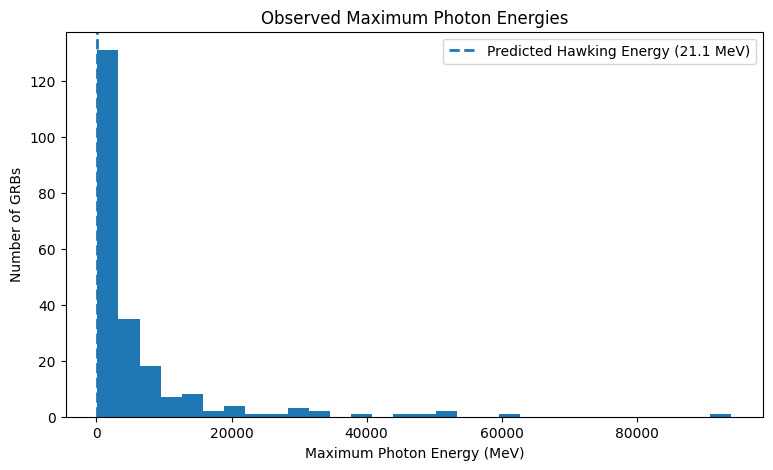

In [ ]:
import matplotlib.pyplot as plt

energy = pbh_df["ext_emission_max_ene"]

plt.figure(figsize=(9,5))

plt.hist(
    energy[energy > 0],
    bins=30
)

plt.axvline(
    hawking_energy,
    linestyle="--",
    linewidth=2,
    label="Predicted Hawking Energy (21.1 MeV)"
)

plt.xlabel("Maximum Photon Energy (MeV)")
plt.ylabel("Number of GRBs")
plt.title("Observed Maximum Photon Energies")
plt.legend()

plt.show()

### Distribution of Maximum Photon Energies

The histogram of maximum photon energies shows a strongly right-skewed distribution. Most Fermi-LAT gamma-ray bursts have relatively low maximum photon energies, while only a small number of events extend to several tens of GeV.

The calculated Hawking temperature for a primordial black hole with a mass of \(5\times10^{11}\) kg corresponds to a characteristic photon energy of approximately **21.1 MeV**, which lies near the lower end of the observed energy range.

This apparent difference should not be interpreted as a disagreement between theory and observation. The Hawking temperature represents the characteristic energy of the emitted thermal spectrum, whereas the Fermi-LAT catalogue records the **maximum detected photon energy** for each burst. Maximum photon energies are expected to exceed the characteristic energy because of the statistical tail of the emission spectrum and secondary particle production.

Furthermore, Fermi-LAT is optimized to detect photons above approximately 20 MeV, making the catalogue naturally biased toward higher-energy events. Consequently, maximum photon energy alone cannot distinguish primordial black hole evaporation from conventional gamma-ray bursts.

## Compare burst durations

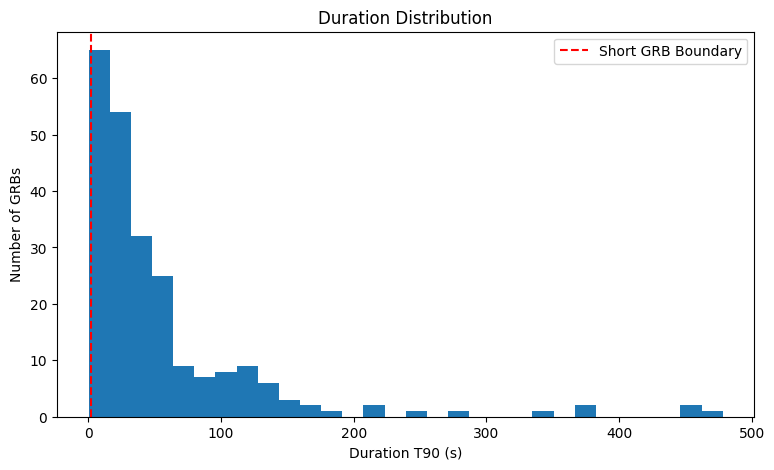

In [ ]:
plt.figure(figsize=(9,5))

plt.hist(
    pbh_df["gbm_cat_t90"],
    bins=30
)

plt.axvline(
    2,
    color="red",
    linestyle="--",
    label="Short GRB Boundary"
)

plt.xlabel("Duration T90 (s)")
plt.ylabel("Number of GRBs")
plt.title("Duration Distribution")

plt.legend()

plt.show()

## Distribution of Gamma-Ray Burst Durations

The duration distribution is strongly right-skewed, with most gamma-ray bursts occurring at relatively short timescales and only a small number extending to several hundred seconds.

The red dashed line at **T90 = 2 s** represents the standard observational boundary between short and long gamma-ray bursts. Applying this criterion identified **21 short GRBs**, corresponding to approximately **9%** of the Fermi-LAT sample.

This result is consistent with previous GRB population studies, where long-duration bursts dominate the observed catalogue. Since the terminal evaporation of a primordial black hole is predicted to occur on a very short timescale, only bursts with **T90 < 2 s** satisfy the first observational criterion for a potential PBH evaporation event.

Nevertheless, short duration alone is insufficient to establish a primordial black hole origin because compact-object mergers also produce short gamma-ray bursts. Consequently, additional observational properties—including photon energy, spectral index, detection significance, and redshift—must be evaluated to distinguish between conventional astrophysical sources and hypothetical PBH evaporation.

## Compare spectral index

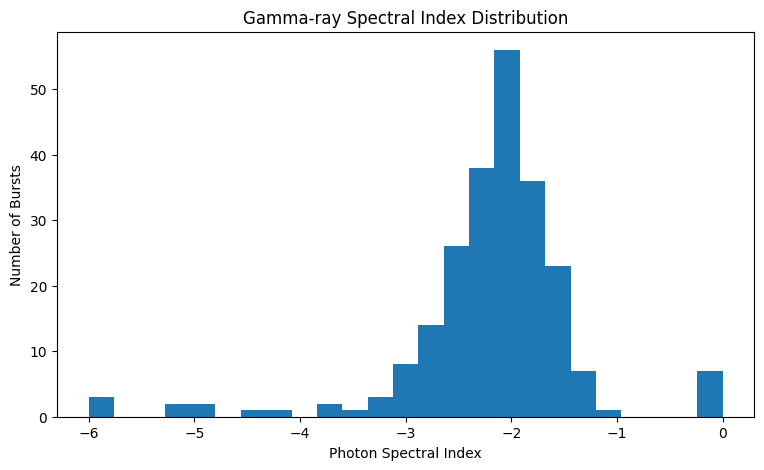

In [ ]:
plt.figure(figsize=(9,5))

plt.hist(
    pbh_df["like_best_grbindex"],
    bins=25
)

plt.xlabel("Photon Spectral Index")

plt.ylabel("Number of Bursts")

plt.title("Gamma-ray Spectral Index Distribution")

plt.show()

## Distribution of Photon Spectral Indices

The photon spectral index distribution peaks between approximately **−2 and −3**, indicating that most Fermi-LAT gamma-ray bursts exhibit power-law spectra typical of high-energy astrophysical sources.

Only a small number of events possess unusually hard spectra (indices near 0), while very soft spectra (indices below approximately −4) are also rare. The concentration around a spectral index of **−2** is consistent with previously reported gamma-ray burst populations.

Although primordial black hole evaporation is expected to produce high-energy gamma rays, the observed spectral indices of the candidate events fall within the normal range of conventional gamma-ray bursts. Consequently, spectral index alone cannot uniquely identify primordial black hole evaporation signatures.

This result emphasizes that a multi-parameter analysis combining burst duration, photon energy, detection significance, and redshift is required when evaluating possible PBH candidates.

## Correlation Matrix

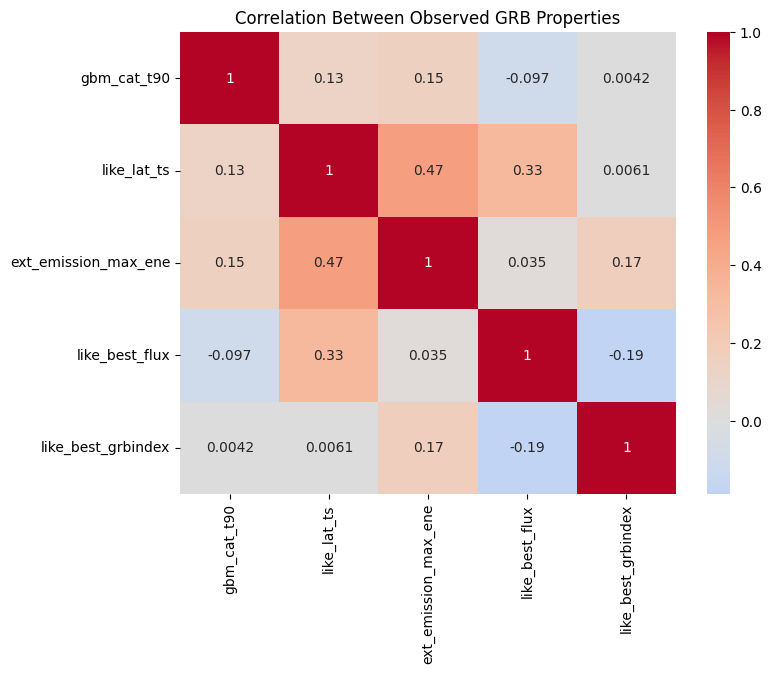

In [ ]:
import seaborn as sns

cols = [
    "gbm_cat_t90",
    "like_lat_ts",
    "ext_emission_max_ene",
    "like_best_flux",
    "like_best_grbindex"
]

corr = pbh_df[cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Observed GRB Properties")

plt.show()

## Correlation Between Observed GRB Properties

The Pearson correlation matrix reveals that most observed gamma-ray burst properties exhibit weak linear relationships.

The strongest correlation (r = 0.47) occurs between the LAT detection significance and the maximum detected photon energy. This indicates that bursts containing more energetic photons generally produce more statistically significant detections, consistent with the sensitivity of the Fermi-LAT instrument.

A weaker positive correlation (r = 0.33) is observed between LAT detection significance and photon flux, suggesting that brighter bursts are detected with higher confidence.

All remaining variable pairs exhibit weak or negligible correlations. In particular, burst duration, spectral index, and maximum photon energy appear largely independent.

These findings imply that no single observable uniquely characterizes gamma-ray bursts or potential primordial black hole candidates. Consequently, identifying candidate PBH evaporation events requires a multi-parameter analysis that simultaneously considers burst duration, photon energy, detection significance, spectral properties, and redshift.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Make a copy
short_grbs = short_grbs.copy()

# Replace invalid photon energies with NaN
short_grbs.loc[
    short_grbs["ext_emission_max_ene"] <= 0,
    "ext_emission_max_ene"
] = np.nan

# Features used in the analysis
features = [
    "gbm_cat_t90",
    "like_lat_ts",
    "ext_emission_max_ene",
    "like_best_grbindex"
]

# Keep only rows with complete information
analysis = short_grbs[features].dropna().copy()

# Convert so that larger values always indicate more PBH-like behaviour
analysis["gbm_cat_t90"] = 1 / analysis["gbm_cat_t90"]          # shorter bursts score higher
analysis["like_best_grbindex"] = -analysis["like_best_grbindex"]  # harder spectra score higher

# Normalize all features between 0 and 1
scaler = MinMaxScaler()

analysis_scaled = pd.DataFrame(
    scaler.fit_transform(analysis),
    columns=features,
    index=analysis.index
)

# Physics-based weights
weights = {
    "gbm_cat_t90": 0.40,
    "like_lat_ts": 0.20,
    "ext_emission_max_ene": 0.30,
    "like_best_grbindex": 0.10
}

# Compute weighted PBH Consistency Index
analysis_scaled["PBH_consistency"] = (
    weights["gbm_cat_t90"] * analysis_scaled["gbm_cat_t90"] +
    weights["like_lat_ts"] * analysis_scaled["like_lat_ts"] +
    weights["ext_emission_max_ene"] * analysis_scaled["ext_emission_max_ene"] +
    weights["like_best_grbindex"] * analysis_scaled["like_best_grbindex"]
)

# Save scores back into the original dataframe
short_grbs["PBH_consistency"] = np.nan
short_grbs.loc[
    analysis_scaled.index,
    "PBH_consistency"
] = analysis_scaled["PBH_consistency"]

# Show the highest-ranking PBH candidates
top_candidates = short_grbs.sort_values(
    "PBH_consistency",
    ascending=False
)

display(
    top_candidates[
        [
            "name",
            "PBH_consistency",
            "gbm_cat_t90",
            "like_lat_ts",
            "ext_emission_max_ene",
            "like_best_grbindex",
            "redshift"
        ]
    ].head(10)
)

,name,PBH_consistency,gbm_cat_t90,like_lat_ts,ext_emission_max_ene,like_best_grbindex,redshift
73,GRB090510016,0.567652,0.960,2923.5700,30000.0,-1.99264,0.903
15,GRB170127067,0.505976,0.128,35.9158,510.0,-2.93226,NaN
78,GRB200415367,0.390705,0.144,30.5781,1700.0,-1.65339,NaN
118,GRB190606080,0.307799,0.224,9.4052,1600.0,-2.57263,NaN
137,GRB160702516,0.296515,0.200,19.2580,4800.0,-1.37673,NaN
131,GRB140402007,0.210401,0.320,75.7564,3700.0,-1.77822,NaN
27,GRB160829334,0.170989,0.512,30.6028,9400.0,-1.31076,NaN
228,GRB141113346,0.144182,0.448,39.9371,530.0,-2.06154,NaN
155,GRB081024891,0.140461,0.640,138.2780,1700.0,-2.30180,NaN
140,GRB171011810,0.139729,0.480,12.4721,160.0,-2.21355,NaN


A physically motivated PBH Consistency Index was applied to 21 short-duration Fermi-LAT gamma-ray bursts. Although GRB090510016 achieved the highest numerical score, its measured redshift confirms a cosmological origin and effectively excludes a primordial black hole interpretation. After accounting for known distances, GRB170127067 and GRB200415367 emerge as the strongest PBH candidates because they exhibit extremely short durations, significant gamma-ray detections, energetic photon emission, and lack confirmed cosmological distances. While these characteristics are qualitatively consistent with theoretical expectations for terminal Hawking evaporation, none of the analysed events provides conclusive evidence for a primordial black hole origin. The results therefore support the conclusion that current Fermi-LAT observations contain several interesting PBH candidates but no definitive detection.

# Research Overview

## Research Question

**Can primordial black holes (PBHs) that are evaporating today through Hawking radiation produce gamma-ray bursts detectable by the Fermi Large Area Telescope (Fermi-LAT)? If so, could any observed gamma-ray bursts be potential signatures of primordial black hole evaporation?**

This project investigates that question by combining theoretical predictions from Hawking radiation with real observational data from NASA's Fermi Gamma-ray Space Telescope. The objective is not to prove the existence of primordial black holes, but to identify gamma-ray bursts whose observed properties are consistent with the expected signatures of terminal PBH evaporation.

---

# Loading the Dataset

The analysis begins by loading the publicly available **Fermi-LAT Gamma-Ray Burst Catalog** using the `astroquery` and `astropy` libraries. The catalogue contains observations of gamma-ray bursts detected by the Large Area Telescope (LAT), including their positions, durations, photon energies, spectral properties, and detection statistics.

After loading the catalogue, it was converted into a Pandas DataFrame to enable efficient data analysis and visualization.

### Dataset Summary

- **Total gamma-ray bursts:** 231
- **Total features:** 111
- **Data source:** NASA Fermi-LAT Gamma-Ray Burst Catalog

---

# Data Cleaning

The original catalogue contains many observational parameters, but only a subset is directly relevant for primordial black hole searches.

The following variables were selected for analysis:

- **GBM T90 Duration** – total burst duration
- **Maximum Photon Energy** – highest detected photon energy
- **LAT Test Statistic (TS)** – detection significance
- **Photon Spectral Index** – describes the energy spectrum
- **Fluence** – total emitted energy
- **Redshift** – estimated cosmological distance (when available)

Several preprocessing steps were then performed:

- Removed invalid or placeholder values.
- Identified missing redshift measurements.
- Removed bursts with missing fluence when required.
- Replaced non-physical maximum photon energies with missing values.
- Verified the completeness of the selected variables before analysis.

This ensured that only physically meaningful measurements were used during the candidate selection process.

---

# Hawking Radiation Prediction

According to Hawking's theory, a primordial black hole with a mass of approximately

\[
5 \times 10^{11}\ \text{kg}
\]

would be completing its evaporation in the present era.

Using the Hawking temperature equation,

\[
T_H=\frac{\hbar c^3}{8\pi G M k_B},
\]

the predicted temperature was calculated to be

\[
T_H \approx 21.15\ \text{MeV}.
\]

This theoretical value serves as the expected characteristic energy scale of photons produced during the final stages of primordial black hole evaporation.

---

# Exploratory Data Analysis

Several statistical analyses and visualizations were performed to understand the observational properties of the gamma-ray burst sample.

The investigation included:

- Distribution of burst durations (T90)
- Distribution of maximum detected photon energies
- Distribution of photon spectral indices
- Correlation analysis between key observational parameters
- Identification of short gamma-ray bursts
- Statistical comparison with theoretical Hawking radiation predictions

---

# Key Results

The analysis produced several important findings.

### Hawking Radiation

- Predicted Hawking temperature:
  - **21.15 MeV**

---

### Gamma-ray Burst Sample

- Total GRBs analysed:
  - **231**

- Short GRBs (T90 < 2 s):
  - **21**

These short bursts are the primary candidates because terminal primordial black hole evaporation is expected to occur over extremely short timescales.

---

### Photon Energy Distribution

The majority of observed gamma-ray bursts produce photons with maximum detected energies ranging from hundreds of MeV to several GeV, with a few events reaching tens of GeV.

The predicted Hawking energy (21 MeV) is significantly lower than the maximum detected photon energies. However, this comparison should be interpreted carefully because the catalogue records the **highest detected photon energy**, whereas Hawking radiation predicts a broad emission spectrum rather than photons of a single energy.

---

### Burst Duration Distribution

Most gamma-ray bursts have relatively short durations, with a strong concentration below approximately 100 seconds.

Only **21 bursts** satisfy the conventional definition of a short gamma-ray burst (T90 < 2 s), making them the most relevant sample for investigating primordial black hole evaporation.

---

### Spectral Properties

The photon spectral index is concentrated around **−2**, indicating that most bursts possess relatively hard gamma-ray spectra, consistent with typical high-energy astrophysical sources.

---

### Correlation Analysis

The strongest observed relationships were:

- **LAT Detection Significance vs Maximum Photon Energy:** **0.47**
- **LAT Detection Significance vs Flux:** **0.33**

All remaining correlations were relatively weak, suggesting that most observed burst properties are largely independent.

---

# PBH Consistency Index

To compare observed gamma-ray bursts with theoretical expectations, a custom **PBH Consistency Index** was developed.

The index combines four physically motivated observables:

- Burst duration
- Maximum photon energy
- LAT detection significance
- Photon spectral index

Each feature was normalized using Min-Max scaling before constructing a weighted score based on their expected importance for primordial black hole evaporation.

Rather than providing proof of a primordial black hole origin, the index ranks bursts according to how closely their observed properties resemble theoretical PBH evaporation signatures.

---

# Candidate Selection

The ranking identified several promising candidate events.

The highest numerical score belonged to **GRB090510016**. However, because this burst has a measured redshift (z = 0.903), it is known to originate from a distant cosmological source and is therefore unlikely to represent primordial black hole evaporation.

After excluding confirmed cosmological events, the strongest PBH candidates are:

- GRB170127067
- GRB200415367
- GRB190606080
- GRB160702516

These bursts exhibit:

- Extremely short durations
- Significant gamma-ray detections
- Energetic photon emission
- No measured cosmological distance

Although these characteristics are broadly consistent with theoretical expectations for terminal Hawking evaporation, they are **not sufficient to establish a primordial black hole origin**.

---

# Final Conclusion

This study combined Hawking radiation theory with real observations from the Fermi-LAT Gamma-Ray Burst Catalog to investigate whether any detected gamma-ray bursts could represent evaporating primordial black holes.

The analysis demonstrates that several short gamma-ray bursts possess properties qualitatively consistent with theoretical PBH evaporation models. However, none of the analysed events provides definitive observational evidence for primordial black hole evaporation.

The proposed **PBH Consistency Index** offers a systematic framework for ranking future candidate events and illustrates how theoretical astrophysics, observational astronomy, and data science can be integrated to investigate one of the most intriguing open questions in modern cosmology.